In [1]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import (
    CXGate,
    RZXGate,
    SwapGate,
    UGate,
    UnitaryGate,
    XXPlusYYGate,
    iSwapGate,
)

from gulps.utils.invariants import GateInvariants
from gulps.utils.visualize import render_path
from qiskit.quantum_info.random import random_unitary
from gulps.cts_linear_program import ContinuousISAConstraints
import numpy as np


def fsim(theta, phi):
    _fsim = QuantumCircuit(2, name="fsim")
    _fsim.append(XXPlusYYGate(2 * theta), [0, 1])
    _fsim.cp(phi, 0, 1)
    return _fsim.to_gate()

In [2]:
base = GateInvariants.from_unitary(fsim(np.pi / 2, np.pi / 6).power(1.0))
solver = ContinuousISAConstraints(base=base, sequence_length=8, offset=1e-6)

[0.935064935064935, 0.07792207792207785, 0.07792207792207788] 1.0909090909090908


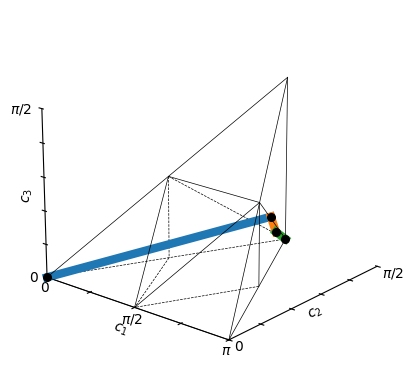

In [3]:
target = GateInvariants.from_unitary(iSwapGate())
solver.set_target(target, rho_bool=False)

gi_list, intermediates, ks = solver.solve(log_output=False)
print(ks, sum(ks))

from gulps.utils.visualize import render_path

render_path(intermediates);

In [4]:
from gulps.gulps_decomposer import GulpsDecomposer

isa = [
    # (fsim(np.pi / 2, np.pi / 6).power(1.0), 1.0, "fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 2), 1 / 2, "sqrt2fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 3), 1 / 3, "sqrt3fsim"),
    (fsim(np.pi / 2, np.pi / 6).power(1 / 3), 1 / 3, "sqrt3fsim"),
    (fsim(np.pi / 2, np.pi / 6).power(1 / 7), 1 / 7, "sqrt7fsim"),
]
gate_set, costs, names = zip(*isa)
decomposer = GulpsDecomposer(
    gate_set=gate_set, costs=costs, names=names, precompute_polytopes=False
)

1.0952380952380951


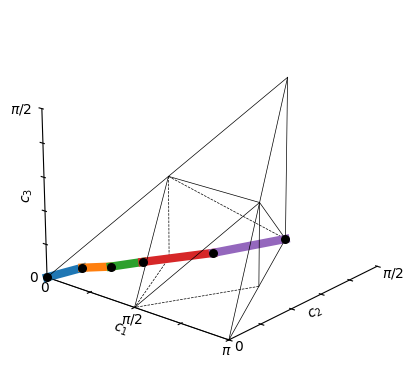

In [5]:
sentence_out, example_intermediates = decomposer._best_decomposition(target_inv=target)
print(sum(decomposer.isa.cost_dict[g] for g in sentence_out))
render_path(example_intermediates);

In [6]:
1.0952380952380951

1.0952380952380951